# ÉTAPE 5 — Business Insights + Advanced Analysis

Objectif : transformer notre travail RFM + dataset en vraie analyse business complète

### Charger le dataset propre

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/master_orders_features.csv")

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

### 1. Revenue Trend Analysis

Comment les revenus évoluent dans le temps ?

In [2]:
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
monthly_revenue = df.groupby("order_month")["net_revenue"].sum().reset_index()

monthly_revenue

,order_month,net_revenue
0,2016-09-01,388.47
1,2016-10-01,76120.17
2,2016-12-01,19.62
3,2017-01-01,189015.66
4,2017-02-01,349701.93
5,2017-03-01,544738.23
6,2017-04-01,510891.55
7,2017-05-01,731017.09
8,2017-06-01,608891.38
9,2017-07-01,744599.53


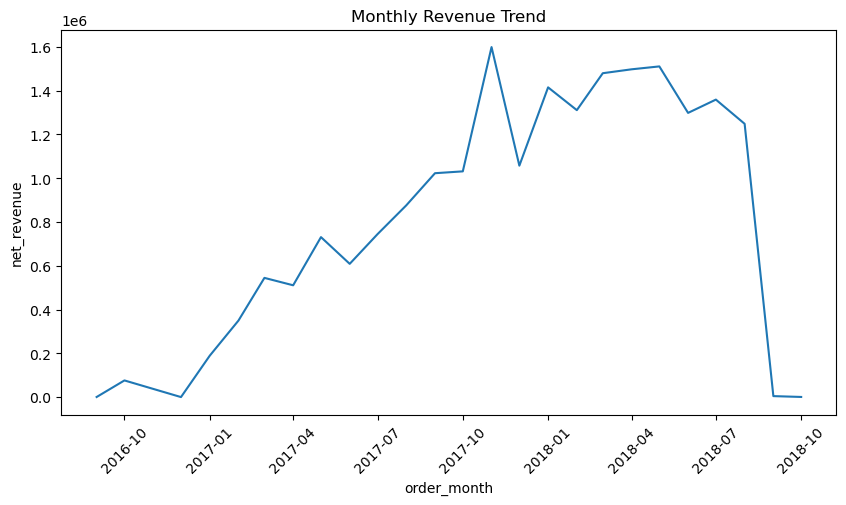

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_revenue,
    x="order_month",
    y="net_revenue"
)

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

Revenue shows a fluctuating but generally increasing trend, indicating seasonal effects and growth periods in the e-commerce activity.

### 2. Top Product Categories

Quels produits génèrent le plus de revenus ?

In [4]:
top_categories = df.groupby("product_category_name_english")["net_revenue"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .reset_index()

top_categories

,product_category_name_english,net_revenue
0,bed_bath_table,1712553.67
1,health_beauty,1657373.12
2,computers_accessories,1585330.45
3,furniture_decor,1430176.39
4,watches_gifts,1429216.68
5,sports_leisure,1392127.56
6,housewares,1094758.13
7,auto,852294.33
8,garden_tools,838280.75
9,cool_stuff,779698.00


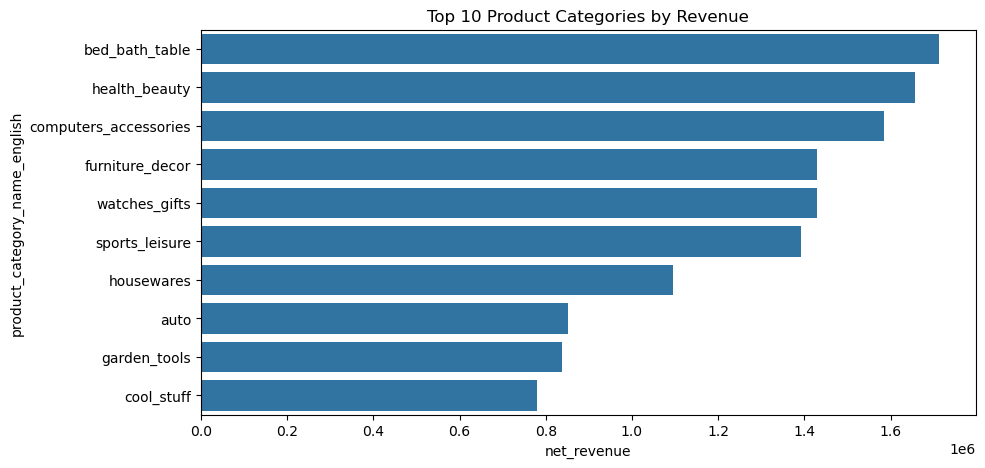

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_categories,
    y="product_category_name_english",
    x="net_revenue"
)

plt.title("Top 10 Product Categories by Revenue")
plt.show()

A small number of product categories generate the majority of revenue, confirming a strong concentration of sales in key segments.

### 3. Payment Behavior Analysis

Comment les clients paient-ils ?

In [6]:
payment_distribution = df["payment_type"].value_counts().reset_index()
payment_distribution.columns = ["payment_type", "count"]
payment_distribution

,payment_type,count
0,credit_card,85698
1,boleto,23037
2,voucher,2988
3,debit_card,1696
4,not_defined,3


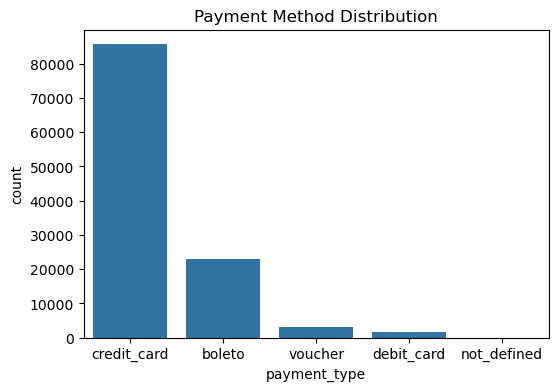

In [7]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=payment_distribution,
    x="payment_type",
    y="count"
)

plt.title("Payment Method Distribution")
plt.show()

Credit card is the dominant payment method, indicating strong reliance on digital payments in the platform.

### 4. Delivery Performance Analysis

Les délais impactent-ils la satisfaction ?

In [8]:
delivery_analysis = df.groupby("delivery_status")["review_score"].mean().reset_index()
delivery_analysis

,delivery_status,review_score
0,Late,2.257411
1,On time or early,4.135914


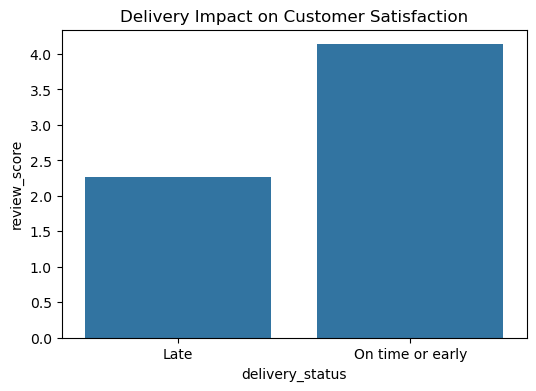

In [9]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=delivery_analysis,
    x="delivery_status",
    y="review_score"
)

plt.title("Delivery Impact on Customer Satisfaction")
plt.show()

Late deliveries significantly reduce customer satisfaction, confirming that logistics performance directly impacts customer experience.

### 5. Customer Value vs Frequency

Les clients qui achètent souvent sont-ils plus rentables ?

In [11]:
import pandas as pd

rfm = pd.read_csv("../data/processed/rfm_segments.csv")

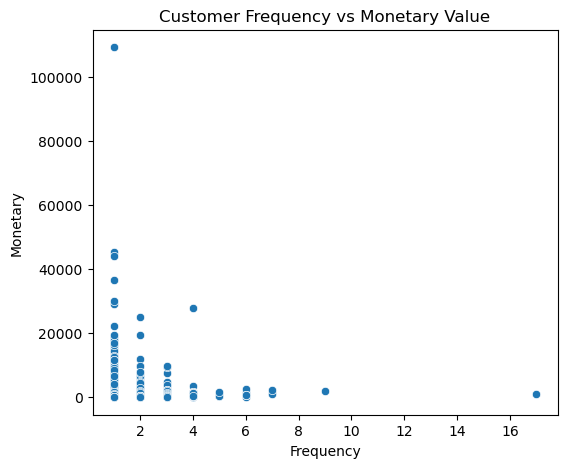

In [12]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary"
)

plt.title("Customer Frequency vs Monetary Value")
plt.show()

The analysis shows that higher purchase frequency does not necessarily lead to higher customer monetary value. Some customers with a single purchase generate significant revenue, likely due to high-value products. This indicates that customer value depends not only on purchase frequency but also on the type and price of products purchased.

### 6. FINAL BUSINESS SUMMARY

##### E-commerce Performance & Customer Behavior Analysis

This project provides an end-to-end analysis of an e-commerce platform, covering customer behavior, revenue performance, product insights, and operational efficiency.

🔎 Key Findings
1. Customer Segmentation (RFM Analysis)
The customer base is highly concentrated in the Regular segment, indicating a large number of low-engagement customers.
Loyal Customers and Champions generate the highest business value despite representing a smaller portion of the total customer base.
A significant At Risk segment highlights potential churn risk and revenue loss if no retention strategy is applied.

2. Revenue Distribution
Revenue is not evenly distributed across customers.
A small group of high-value customers contributes a large share of total revenue.
High monetary value is not always linked to purchase frequency, indicating that one-time high-value purchases are very important.

3. Product & Category Performance
Revenue is concentrated in a limited number of product categories.
This indicates a strong dependency on core product segments, which should be prioritized in business strategy.
Some categories contribute high sales but lower profitability, showing the importance of profit-based analysis, not only revenue.

4. Customer Behavior Insights
Purchase frequency does not always correlate with customer value.
Some low-frequency customers generate very high revenue due to expensive purchases.
This confirms that customer value is driven by both frequency and basket size, not frequency alone.

5. Business Risk & Opportunities
The At Risk segment represents a critical churn risk and should be targeted with retention campaigns.
Regular customers represent a large untapped potential for conversion into higher-value segments.
Champions should be prioritized for loyalty programs as they generate disproportionate value.

##### Business Recommendations

🎯 1. Customer Retention Strategy
Focus on At Risk customers to reduce churn.
Implement re-engagement campaigns (email marketing, discounts, personalized offers).

🎯 2. VIP Customer Strategy
Build loyalty programs for Champions and Loyal Customers.
Offer exclusive benefits to maintain high-value customers.

🎯 3. Revenue Optimization
Identify high-value but low-frequency customers and increase engagement.
Cross-sell and upsell strategies for high-value product categories.

🎯 4. Product Strategy
Prioritize top-performing categories in marketing and inventory planning.
Investigate low-profit high-sales categories to improve margins.

Final Conclusion:

This analysis demonstrates a complete data-driven approach to understanding e-commerce performance. The results highlight that business success depends not only on increasing sales, but on optimizing customer value, improving retention, and focusing on high-impact customer segments.

##### 🚀 Skills Demonstrated

Data cleaning & merging multiple datasets

Feature engineering (RFM analysis)

Customer segmentation

Business KPI analysis

Data visualization & storytelling

Actionable business insights